<a href="https://colab.research.google.com/github/swathivenkatesan87/24ADI003_24BAD122-EXP-4/blob/main/Ex_4(2)_24BAD122.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Swathi
Roll No: 24BAD122
Gaussian Naive Bayes – Iris Classification

First 5 Rows:
   sepal_length  sepal_width  petal_length  petal_width      species
0           4.9          3.0           1.4          0.2  Iris-setosa
1           4.7          3.2           1.3          0.2  Iris-setosa
2           4.6          3.1           1.5          0.2  Iris-setosa
3           5.0          3.6           1.4          0.2  Iris-setosa
4           5.4          3.9           1.7          0.4  Iris-setosa

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  149 non-null    float64
 1   sepal_width   149 non-null    float64
 2   petal_length  149 non-null    float64
 3   petal_width   149 non-null    float64
 4   species       149 non-null    object 
dtypes: float64(4), object(1)
memory usage: 5.9+ KB
None

Missing Values:
sep

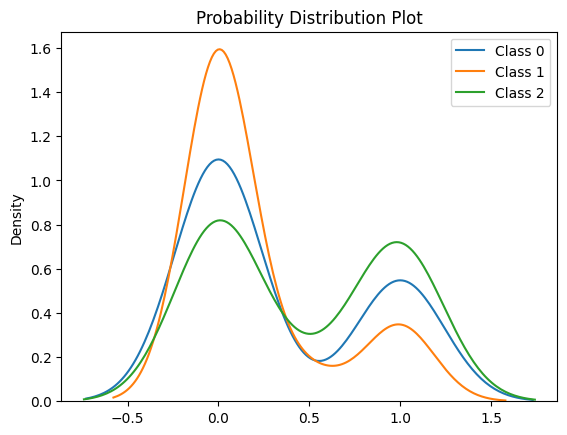


Logistic Regression Accuracy: 0.9


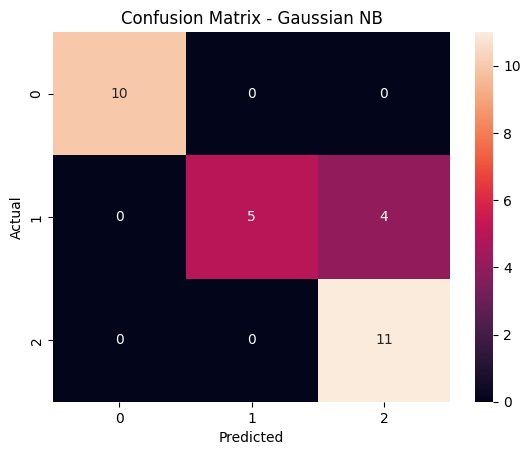

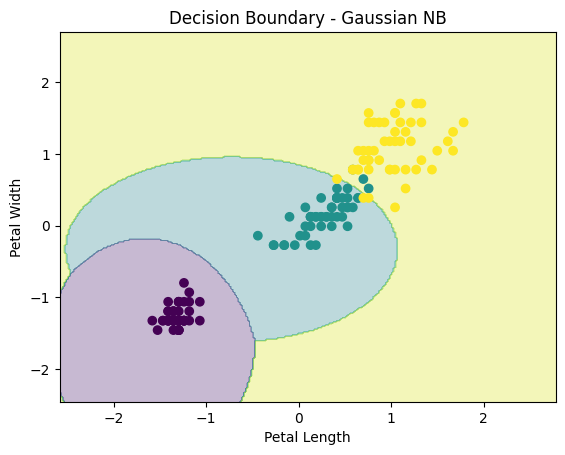


Program Completed Successfully
Name: Swathi | Roll No: 24BAD122


In [ ]:
# 1. Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Name: Swathi")
print("Roll No: 24BAD122")
print("Gaussian Naive Bayes – Iris Classification")

# 2. Load Iris dataset (CSV file)
df = pd.read_csv("iris.data.csv")

# Assign column names (if dataset has no header)
df.columns = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width",
    "species"
]

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

# 3. Preprocessing
# Encode categorical target variable
le = LabelEncoder()
df['species'] = le.fit_transform(df['species'])

# Features and target
X = df[['sepal_length','sepal_width','petal_length','petal_width']]
y = df['species']

# 4. Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# 6. Train Gaussian Naive Bayes Model
gnb = GaussianNB()
gnb.fit(X_train, y_train)

# 7. Predictions
y_pred = gnb.predict(X_test)

# 8. Evaluation Metrics
print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 9. Compare Predictions with Actual Labels
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print("\nActual vs Predicted:")
print(comparison.head(10))

# 10. Class Probabilities
probabilities = gnb.predict_proba(X_test)

print("\nClass Probabilities (First 5 rows):")
print(probabilities[:5])

# Probability distribution plot
plt.figure()
for i in range(probabilities.shape[1]):
    sns.kdeplot(probabilities[:, i], label="Class " + str(i))
plt.title("Probability Distribution Plot")
plt.legend()
plt.show()

# 11. Logistic Regression Comparison (Optional)
lr = LogisticRegression(max_iter=200)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("\nLogistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_lr))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Gaussian NB")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Decision Boundary using two features
# (petal_length & petal_width)
X2 = df[['petal_length','petal_width']]
X2 = StandardScaler().fit_transform(X2)

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y, test_size=0.2, random_state=42
)

model = GaussianNB()
model.fit(X2_train, y2_train)

h = 0.02
x_min, x_max = X2[:, 0].min() - 1, X2[:, 0].max() + 1
y_min, y_max = X2[:, 1].min() - 1, X2[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure()
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X2[:, 0], X2[:, 1], c=y)
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Decision Boundary - Gaussian NB")
plt.show()

print("\nProgram Completed Successfully")
print("Name: Swathi | Roll No: 24BAD122")